In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris

In [5]:
#Load Iris Dataset
iris = load_iris(as_frame=True)

In [8]:
df = iris.frame
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [9]:
target_names = dict(enumerate(iris.target_names));
print(target_names)

{0: np.str_('setosa'), 1: np.str_('versicolor'), 2: np.str_('virginica')}


In [12]:
df["Species"]=df["target"].map(target_names)

In [13]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,Species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [18]:
feature_cols = iris.feature_names
X = df[feature_cols]
Y = df["target"]


In [ ]:
X=X.to_numpy()
Y=Y.to_numpy()

In [38]:
print(X)
print(Y)

[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]
 [5.4 3.9 1.7 0.4]
 [4.6 3.4 1.4 0.3]
 [5.  3.4 1.5 0.2]
 [4.4 2.9 1.4 0.2]
 [4.9 3.1 1.5 0.1]
 [5.4 3.7 1.5 0.2]
 [4.8 3.4 1.6 0.2]
 [4.8 3.  1.4 0.1]
 [4.3 3.  1.1 0.1]
 [5.8 4.  1.2 0.2]
 [5.7 4.4 1.5 0.4]
 [5.4 3.9 1.3 0.4]
 [5.1 3.5 1.4 0.3]
 [5.7 3.8 1.7 0.3]
 [5.1 3.8 1.5 0.3]
 [5.4 3.4 1.7 0.2]
 [5.1 3.7 1.5 0.4]
 [4.6 3.6 1.  0.2]
 [5.1 3.3 1.7 0.5]
 [4.8 3.4 1.9 0.2]
 [5.  3.  1.6 0.2]
 [5.  3.4 1.6 0.4]
 [5.2 3.5 1.5 0.2]
 [5.2 3.4 1.4 0.2]
 [4.7 3.2 1.6 0.2]
 [4.8 3.1 1.6 0.2]
 [5.4 3.4 1.5 0.4]
 [5.2 4.1 1.5 0.1]
 [5.5 4.2 1.4 0.2]
 [4.9 3.1 1.5 0.2]
 [5.  3.2 1.2 0.2]
 [5.5 3.5 1.3 0.2]
 [4.9 3.6 1.4 0.1]
 [4.4 3.  1.3 0.2]
 [5.1 3.4 1.5 0.2]
 [5.  3.5 1.3 0.3]
 [4.5 2.3 1.3 0.3]
 [4.4 3.2 1.3 0.2]
 [5.  3.5 1.6 0.6]
 [5.1 3.8 1.9 0.4]
 [4.8 3.  1.4 0.3]
 [5.1 3.8 1.6 0.2]
 [4.6 3.2 1.4 0.2]
 [5.3 3.7 1.5 0.2]
 [5.  3.3 1.4 0.2]
 [7.  3.2 4.7 1.4]
 [6.4 3.2 4.5 1.5]
 [6.9 3.1 4.

In [23]:
col_means = X.mean(axis=0)
col_stds = X.std(axis=0,ddof=0)
print("\n Numpy column means:",col_means)
print("\n Numpy column stds:",col_stds)


 Numpy column means: [5.84333333 3.05733333 3.758      1.19933333]

 Numpy column stds: [0.82530129 0.43441097 1.75940407 0.75969263]


In [26]:
print("Missing values in the dataframe:")
print(df.isnull().sum())
df.groupby("Species")[feature_cols].mean()

Missing values in the dataframe:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
Species              0
dtype: int64


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
Species,,,,
setosa,5.006,3.428,1.462,0.246
versicolor,5.936,2.770,4.260,1.326
virginica,6.588,2.974,5.552,2.026


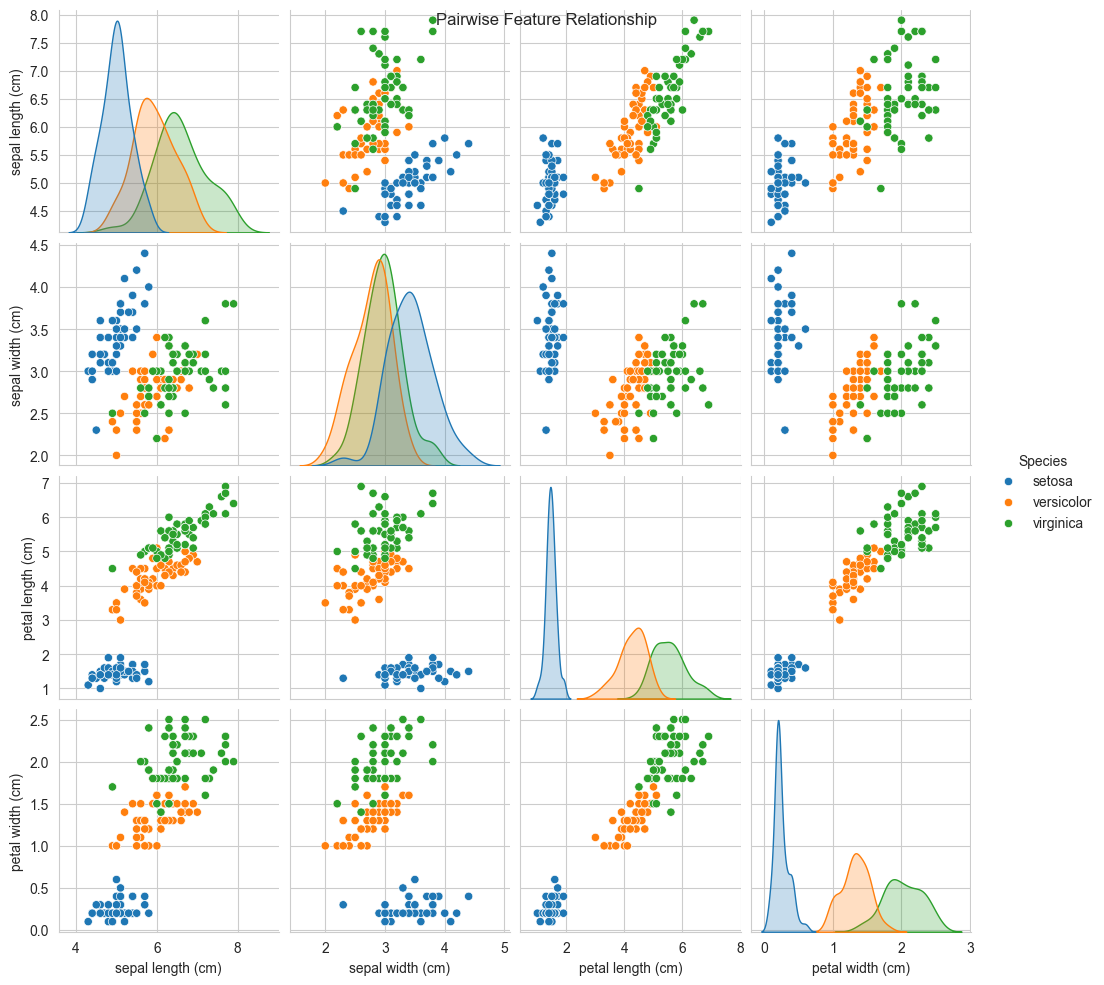

In [30]:
#Pair plot with Seaborn
sns.set_style("whitegrid")

sns.pairplot(df[feature_cols+["Species"]],hue="Species",diag_kind="kde")
plt.suptitle("Pairwise Feature Relationship")
plt.show()

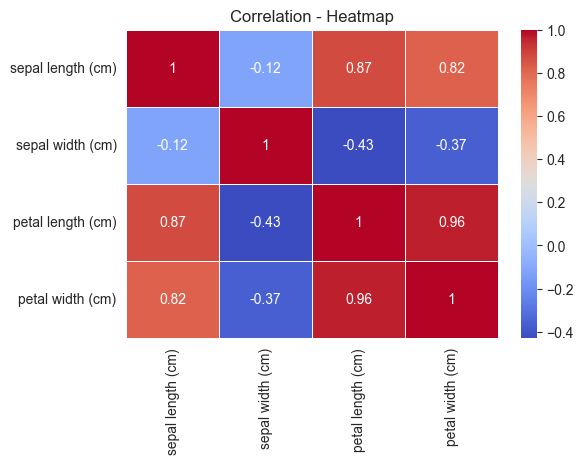

In [31]:
corr=df[feature_cols].corr(numeric_only = True)
plt.figure(figsize=(6,4))
sns.heatmap(corr,annot = True,cmap = "coolwarm",linewidths=0.5)
plt.title("Correlation - Heatmap")
plt.show()

In [33]:
arr = np.array([[1, 2, 3], [4, 5, 6]])
arr.shape
result = arr*2
print(result)

[[ 2  4  6]
 [ 8 10 12]]
